# English Human Dataset — Diverse Sources

## Problem
The previous English Human dataset (250K samples) came **only from Wikipedia chunks**.  
The AI data (from RAID) covers domains like **news, books, abstracts, reviews**.  
This caused a **domain shift** — the model learned:  
- "Wikipedia encyclopedic style = Human"  
- "Everything else = AI"  

## Fix
Rebuild the English Human dataset with diverse sources matching the AI data domains.

### Target: 250,000 balanced human samples
| Source | Target Count |
|---|---|
| News (cc_news) | ~70,000 |
| Books (bookcorpus) | ~60,000 |
| Abstracts (scientific_papers — arxiv) | ~60,000 |
| Wikipedia (wikimedia/wikipedia) | ~60,000 |

All datasets loaded via HuggingFace `datasets` with `streaming=True`.

Human data collection (news, books, abstracts, wiki)
Short samples
Combine all sources
Clean + Dedup
Load RAID AI data
Merge human + AI
← Plot 1: Label Distribution (هنا بتشوف التوازن)
← Plot 2: Word Count by Label (هنا بتقارن human vs AI)
← Plot 3: CDF (هنا بتشوف الـ coverage)
Balance (sample human to match AI)
Save

In [1]:
# Cell 1: Imports and shared utilities

import pandas as pd
import numpy as np
import random
import re
from datasets import load_dataset

random.seed(42)
np.random.seed(42)

# --- Chunking function ---
def chunk_text(text, min_words=150, max_words=450):
    """Chunk a document into pieces of 150–450 words (random size).
    Only keep chunks with >= 100 words."""
    words = text.split()
    chunks = []
    i = 0
    while i < len(words):
        size = random.randint(min_words, max_words)
        chunk = " ".join(words[i:i+size])
        if len(chunk.split()) >= 100:
            chunks.append(chunk)
        i += size
    return chunks

# --- Minimal cleaning function ---
def clean(text):
    """Minimal cleaning for AI detection.
    Preserves: punctuation, quotes, stopwords, casing — all are signal.
    Does NOT use spaCy. Does NOT remove punctuation."""
    if not isinstance(text, str) or not text.strip():
        return None
    # Normalize unicode whitespace
    text = re.sub(r"[\xa0\u200b\u200c\u200d\u2060\ufeff]", " ", text)
    # Collapse all whitespace into single space
    text = re.sub(r"\s+", " ", text).strip()
    # Drop short texts
    if len(text.split()) < 100:
        return None
    return text

print("Utilities loaded ✅")

Utilities loaded ✅


---
## Source 1: News (~70,000 samples)
Dataset: `cc_news`, split `train`

In [2]:
# Cell 2: Collect News samples from cc_news

TARGET_NEWS = 70_000

print("Loading cc_news (streaming)...")
news_dataset = load_dataset("cc_news", split="train", streaming=True)

news_texts = []
count = 0
news_iterator = iter(news_dataset) # <--- أضفنا هذا السطر
for entry in news_iterator:
    text = entry.get("text", "")
    if text and len(text) > 1500:
        chunks = chunk_text(text)
        news_texts.extend(chunks)
    count += 1
    if len(news_texts) >= TARGET_NEWS:
        break
    if len(news_texts) % 10_000 == 0 and len(news_texts) > 0:
        print(f"  News: {len(news_texts):,} chunks collected (from {count:,} articles)")

news_texts = news_texts[:TARGET_NEWS]
print(f"\n✅ News collection done: {len(news_texts):,} chunks from {count:,} articles")

Loading cc_news (streaming)...


README.md: 0.00B [00:00, ?B/s]

  News: 10,000 chunks collected (from 9,263 articles)
  News: 20,000 chunks collected (from 16,841 articles)
  News: 20,000 chunks collected (from 16,842 articles)
  News: 30,000 chunks collected (from 25,190 articles)
  News: 40,000 chunks collected (from 33,539 articles)
  News: 60,000 chunks collected (from 50,141 articles)
  News: 60,000 chunks collected (from 50,142 articles)
  News: 60,000 chunks collected (from 50,143 articles)

✅ News collection done: 70,000 chunks from 57,392 articles


---
## Source 2: Books (~60,000 samples)
Dataset: `bookcorpus`, split `train`

In [3]:
# Cell 3: Collect Books samples from Gutenberg
TARGET_BOOKS = 60_000

print("Loading gutenberg books (streaming)...")
books_dataset = load_dataset(
    "manu/project_gutenberg",
    split="en",
    streaming=True
)

books_texts = []

books_iterator = iter(books_dataset) # <--- أضفنا هذا السطر
for entry in books_iterator:
    text = entry.get("text", "")
    if not text.strip():
        continue
    chunks = chunk_text(text)
    books_texts.extend(chunks)
    
    if len(books_texts) >= TARGET_BOOKS:
        break
    
    if len(books_texts) % 10_000 == 0 and len(books_texts) > 0:
        print(f"  Books: {len(books_texts):,} chunks collected")

books_texts = books_texts[:TARGET_BOOKS]
print(f"\n✅ Books done: {len(books_texts):,} chunks")

Loading gutenberg books (streaming)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]


✅ Books done: 60,000 chunks


---
## Source 3: Academic Abstracts (~60,000 samples)
Dataset: `scientific_papers`, config `arxiv`, split `train`, column `abstract`

In [4]:
# Cell 4: Collect Abstracts
TARGET_ABSTRACTS = 60_000

print("Loading arxiv abstracts (streaming)...")
abstracts_dataset = load_dataset(
    "neuralwork/arxiver",
    split="train",
    streaming=True
)

abstract_texts = []
count = 0

abstracts_iterator = iter(abstracts_dataset) # <--- أضفنا هذا السطر
for entry in abstracts_iterator:
    text = entry.get("abstract", "")
    if not text or len(text.split()) < 50:
        continue
    
    text = text.replace("\n", " ").strip()
    
    if len(text.split()) >= 100:
        abstract_texts.append(text)
    else:
        chunks = chunk_text(text)
        abstract_texts.extend(chunks)
    
    count += 1
    
    if len(abstract_texts) >= TARGET_ABSTRACTS:
        break
    
    if len(abstract_texts) % 10_000 < 5:
        print(f"  Abstracts: {len(abstract_texts):,} collected (from {count:,} papers)")

abstract_texts = abstract_texts[:TARGET_ABSTRACTS]
print(f"\n✅ Abstracts done: {len(abstract_texts):,} from {count:,} papers")

Loading arxiv abstracts (streaming)...


README.md: 0.00B [00:00, ?B/s]

  Abstracts: 1 collected (from 1 papers)
  Abstracts: 2 collected (from 2 papers)
  Abstracts: 2 collected (from 3 papers)
  Abstracts: 3 collected (from 4 papers)
  Abstracts: 4 collected (from 5 papers)
  Abstracts: 10,000 collected (from 11,362 papers)
  Abstracts: 10,000 collected (from 11,363 papers)
  Abstracts: 10,001 collected (from 11,364 papers)
  Abstracts: 10,002 collected (from 11,365 papers)
  Abstracts: 10,002 collected (from 11,366 papers)
  Abstracts: 10,003 collected (from 11,367 papers)
  Abstracts: 10,003 collected (from 11,368 papers)
  Abstracts: 10,004 collected (from 11,369 papers)
  Abstracts: 20,000 collected (from 22,777 papers)
  Abstracts: 20,001 collected (from 22,778 papers)
  Abstracts: 20,002 collected (from 22,779 papers)
  Abstracts: 20,003 collected (from 22,780 papers)
  Abstracts: 20,004 collected (from 22,781 papers)
  Abstracts: 30,000 collected (from 34,258 papers)
  Abstracts: 30,001 collected (from 34,259 papers)
  Abstracts: 30,002 collected 

---
## Source 4: Wikipedia (~60,000 samples)
Dataset: `wikimedia/wikipedia`, config `20231101.en`, split `train`

In [5]:
# Cell 5: Collect Wikipedia samples

TARGET_WIKI = 60_000

print("Loading wikimedia/wikipedia 20231101.en (streaming)...")
wiki_dataset = load_dataset(
    "wikimedia/wikipedia", "20231101.en", split="train", streaming=True
)

wiki_texts = []
count = 0

wiki_iterator = iter(wiki_dataset) # <--- أضفنا هذا السطر
for entry in wiki_iterator:
    text = entry.get("text", "")
    if text and len(text) > 1500:
        chunks = chunk_text(text)
        wiki_texts.extend(chunks)

    count += 1
    if len(wiki_texts) >= TARGET_WIKI:
        break
    if len(wiki_texts) % 10_000 == 0 and len(wiki_texts) > 0:
        print(f"  Wikipedia: {len(wiki_texts):,} chunks collected (from {count:,} articles)")

wiki_texts = wiki_texts[:TARGET_WIKI]
print(f"\n✅ Wikipedia collection done: {len(wiki_texts):,} chunks from {count:,} articles")

Loading wikimedia/wikipedia 20231101.en (streaming)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]


✅ Wikipedia collection done: 60,000 chunks from 15,332 articles


In [6]:
# ===== Short Human Samples (20-99 words) — 5K من كل source =====
TARGET_PER_SOURCE = 5_000

short_human = []

# 1. Wikipedia
print("Wikipedia (Resuming stream)...")
wiki_short = []
# نكمل السحب من wiki_iterator مباشرة
for entry in wiki_iterator:
    for para in entry["text"].split("\n"):
        para = para.strip()
        if 20 <= len(para.split()) <= 99:
            wiki_short.append(para)
        if len(wiki_short) >= TARGET_PER_SOURCE:
            break
    if len(wiki_short) >= TARGET_PER_SOURCE:
        break
short_human.extend(wiki_short)
print(f"  ✅ Wikipedia: {len(wiki_short):,}")

# 2. CC-News
print("CC-News (Resuming stream)...")
news_short = []
for entry in news_iterator:
    for para in entry["text"].split("\n"):
        para = para.strip()
        if 20 <= len(para.split()) <= 99:
            news_short.append(para)
        if len(news_short) >= TARGET_PER_SOURCE:
            break
    if len(news_short) >= TARGET_PER_SOURCE:
        break
short_human.extend(news_short)
print(f"  ✅ CC-News: {len(news_short):,}")

# 3. Gutenberg
print("Gutenberg (Resuming stream)...")
books_short = []
for entry in books_iterator:
    for para in entry["text"].split("\n"):
        para = para.strip()
        if 20 <= len(para.split()) <= 99:
            books_short.append(para)
        if len(books_short) >= TARGET_PER_SOURCE:
            break
    if len(books_short) >= TARGET_PER_SOURCE:
        break
short_human.extend(books_short)
print(f"  ✅ Gutenberg: {len(books_short):,}")

# 4. ArXiv
print("ArXiv (Resuming stream)...")
arxiv_short = []
for entry in abstracts_iterator:
    text = entry.get("abstract", "")
    if not text:
        continue
    for para in text.split("\n"):
        para = para.strip()
        if 20 <= len(para.split()) <= 99:
            arxiv_short.append(para)
    
    if 20 <= len(text.split()) <= 99:
        arxiv_short.append(text.strip())
        
    if len(arxiv_short) >= TARGET_PER_SOURCE:
        break

short_human.extend(arxiv_short[:TARGET_PER_SOURCE])
print(f"  ✅ ArXiv: {len(arxiv_short[:TARGET_PER_SOURCE]):,}")


# ===== DataFrame =====
# إعطاء الـ source للعينات القصيرة كما اتفقنا سابقاً
short_sources = (
    ["wikipedia"] * len(wiki_short[:TARGET_PER_SOURCE]) +
    ["news"] * len(news_short[:TARGET_PER_SOURCE]) +
    ["books"] * len(books_short[:TARGET_PER_SOURCE]) +
    ["abstracts"] * len(arxiv_short[:TARGET_PER_SOURCE])
)

df_short_human = pd.DataFrame({
    "text": short_human[:20_000],
    "label": 0,
    "source": short_sources[:20_000]
})

df_short_human = df_short_human.drop_duplicates(subset=["text"])
df_short_human = df_short_human.dropna(subset=["text"])

print(f"\n✅ Total short human: {len(df_short_human):,}")
print("Short sources distribution:")
print(df_short_human.groupby("source").size())

Wikipedia (Resuming stream)...
  ✅ Wikipedia: 5,000
CC-News (Resuming stream)...
  ✅ CC-News: 5,000
Gutenberg (Resuming stream)...
  ✅ Gutenberg: 5,000
ArXiv (Resuming stream)...
  ✅ ArXiv: 0

✅ Total short human: 12,143
Short sources distribution:
source
books        3208
news         3948
wikipedia    4987
dtype: int64


---
## Combine, Clean, and Save

In [7]:
# Cell 6: Combine all sources into one DataFrame
print("=" * 60)
print("COMBINING ALL SOURCES")
print("=" * 60)

all_texts = []

# Long samples (100+ words)
for text in news_texts:
    all_texts.append({"text": text, "label": 0, "source": "news"})
for text in books_texts:
    all_texts.append({"text": text, "label": 0, "source": "books"})
for text in abstract_texts:
    all_texts.append({"text": text, "label": 0, "source": "abstracts"})
for text in wiki_texts:
    all_texts.append({"text": text, "label": 0, "source": "wikipedia"})

# Short samples (20-99 words)
for _, row in df_short_human.iterrows():
    all_texts.append({"text": row["text"], "label": 0, "source": "short_docs"})

df_human = pd.DataFrame(all_texts)

print(f"Total samples before cleaning: {len(df_human):,}")
print(f"\nSource distribution:")
print(df_human["source"].value_counts())

# Free memory
del news_texts, books_texts, abstract_texts, wiki_texts
print("\nRaw data combined ✅")

COMBINING ALL SOURCES
Total samples before cleaning: 256,123

Source distribution:
source
news          70000
books         60000
wikipedia     60000
abstracts     53980
short_docs    12143
Name: count, dtype: int64

Raw data combined ✅


In [8]:
# Cell 7: Apply cleaning, dedup, and save
print("Applying cleaning function...")

# ✅ cleaning مختلف للـ short samples
def clean_short(text):
    if not isinstance(text, str) or not text.strip():
        return None
    text = re.sub(r"[\xa0\u200b\u200c\u200d\u2060\ufeff]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if len(text.split()) < 20:
        return None
    return text

# طبّق الـ clean المناسب على كل row
def apply_clean(row):
    if len(row["text"].split()) < 100:
        return clean_short(row["text"])
    else:
        return clean(row["text"])

df_human["text"] = df_human.apply(apply_clean, axis=1)

before = len(df_human)
df_human = df_human.dropna(subset=["text"])
after = len(df_human)
print(f"  Dropped (nulls/short): {before - after:,}")

before = len(df_human)
df_human = df_human.drop_duplicates(subset=["text"])
after = len(df_human)
print(f"  Dropped (duplicates): {before - after:,}")

print(f"\nRemaining: {len(df_human):,}")
print(f"\nSource distribution after cleaning:")
print(df_human["source"].value_counts())

# Save
df_final = df_human[["text", "label"]].copy()
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)
df_final.to_csv("english_human_diverse.csv", index=False)

print(f"\n{'=' * 60}")
print(f"FINAL DATASET")
print(f"{'=' * 60}")
print(f"Total samples: {len(df_final):,}")
print(f"\nLabel distribution:")
print(df_final["label"].value_counts())
print(f"\nSaved as 'english_human_diverse.csv' ✅")

Applying cleaning function...
  Dropped (nulls/short): 0
  Dropped (duplicates): 251

Remaining: 255,872

Source distribution after cleaning:
source
news          69770
wikipedia     60000
books         59983
abstracts     53977
short_docs    12142
Name: count, dtype: int64

FINAL DATASET
Total samples: 255,872

Label distribution:
label
0    255872
Name: count, dtype: int64

Saved as 'english_human_diverse.csv' ✅


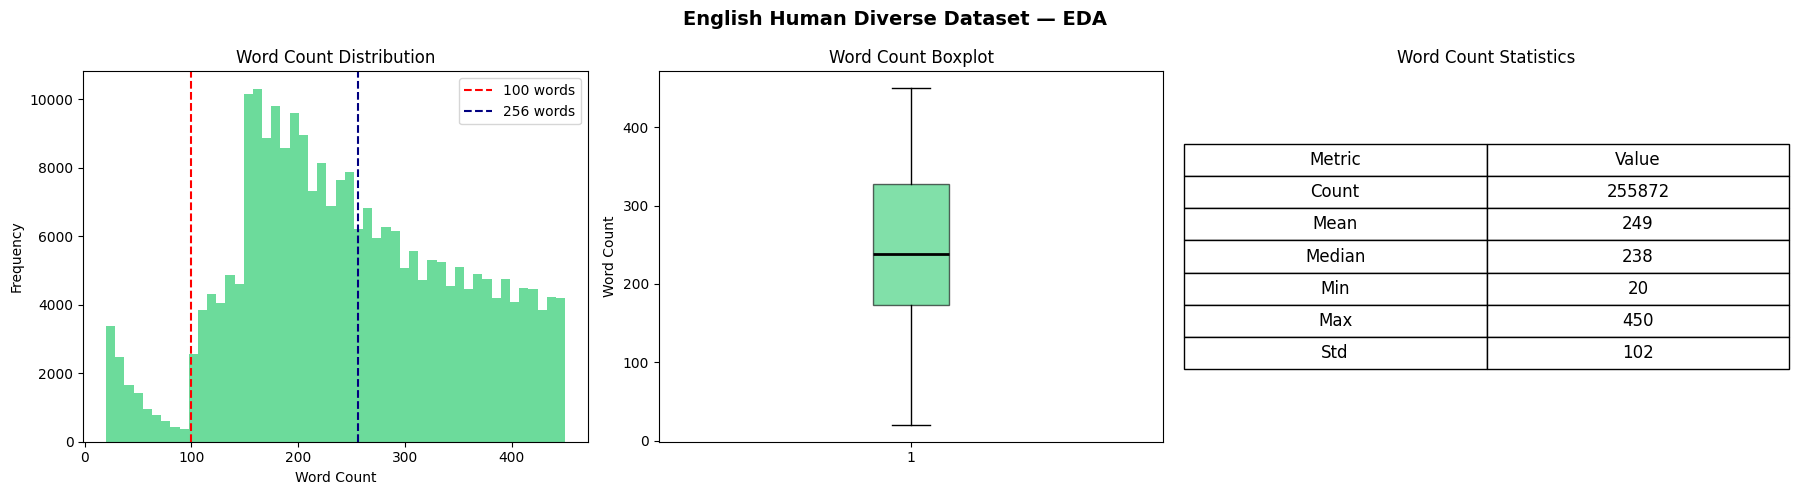

=== Word Count Stats ===
Mean   : 249
Median : 238
Min    : 20
Max    : 450

% texts > 256 words: 43.9%


In [9]:
# Cell 8: Quick EDA on the final dataset

import matplotlib.pyplot as plt

df_final["word_count"] = df_final["text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("English Human Diverse Dataset — EDA", fontsize=14, fontweight="bold")

# 1. Word Count Distribution
axes[0].hist(df_final["word_count"].clip(upper=500), bins=50, color="#2ecc71", alpha=0.7)
axes[0].axvline(100, color="red", linestyle="--", linewidth=1.5, label="100 words")
axes[0].axvline(256, color="navy", linestyle="--", linewidth=1.5, label="256 words")
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# 2. Word Count Boxplot
axes[1].boxplot(
    df_final["word_count"].clip(upper=600),
    patch_artist=True,
    boxprops=dict(facecolor="#2ecc71", alpha=0.6),
    medianprops=dict(color="black", linewidth=2)
)
axes[1].set_title("Word Count Boxplot")
axes[1].set_ylabel("Word Count")

# 3. Stats Table
stats = df_final["word_count"].describe().round(0)
axes[2].axis("off")
table_data = [
    ["Metric", "Value"],
    ["Count", f"{stats['count']:.0f}"],
    ["Mean", f"{stats['mean']:.0f}"],
    ["Median", f"{stats['50%']:.0f}"],
    ["Min", f"{stats['min']:.0f}"],
    ["Max", f"{stats['max']:.0f}"],
    ["Std", f"{stats['std']:.0f}"],
]
table = axes[2].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
axes[2].set_title("Word Count Statistics")

plt.tight_layout()
plt.savefig("english_human_diverse_eda.png", dpi=150)
plt.show()

print("=== Word Count Stats ===")
print(f"Mean   : {df_final['word_count'].mean():.0f}")
print(f"Median : {df_final['word_count'].median():.0f}")
print(f"Min    : {df_final['word_count'].min():.0f}")
print(f"Max    : {df_final['word_count'].max():.0f}")
print(f"\n% texts > 256 words: {(df_final['word_count'] > 256).mean()*100:.1f}%")

In [10]:
# Cell 9: Sample inspection

print("=" * 60)
print("SAMPLE TEXTS")
print("=" * 60)

for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(df_final["text"].iloc[i][:500])
    print("...")
    print(f"Word count: {df_final['word_count'].iloc[i]}")
    print()

SAMPLE TEXTS

--- Sample 1 ---
for keeping the Project Gutenberg-tm name associated with the work. You can easily comply with the terms of this agreement by keeping this work in the same format with its attached full Project Gutenberg-tm License when you share it without charge with others. 1.D. The copyright laws of the place where you are located also govern what you can do with this work. Copyright laws in most countries are in a constant state of change. If you are outside the United States, check the laws of your country
...
Word count: 300


--- Sample 2 ---
MOSCOW — Declaring a victory in Syria, Russian President Vladimir Putin on Monday visited a Russian military air base in the country and announced a partial pullout of Russian forces from the Mideast nation. Putin’s surprise visit marked his first trip to Syria, drawing a symbolic line under the campaign that has shored up President Bashar Assad’s government. It was also the first visit by a foreign head of state to war-ravag

In [11]:
# Top-up: عوّض النقص من Wikipedia
current_count = len(df_human)
target = 250_000
needed = target - current_count

if needed > 0:
    print(f"Need {needed:,} more samples from Wikipedia...")
    
    wiki_extra = load_dataset(
        "wikimedia/wikipedia", "20231101.en",
        split="train", streaming=True
    )
    
    extra_texts = []
    for entry in wiki_extra:
        if len(entry["text"]) > 1500:
            chunks = chunk_text(entry["text"])
            extra_texts.extend(chunks)
        if len(extra_texts) >= needed:
            break
    
    extra_texts = extra_texts[:needed]
    df_extra = pd.DataFrame({"text": extra_texts, "label": 0})
    df_human = pd.concat([df_human, df_extra], ignore_index=True)
    df_human = df_human.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"✅ Final count: {len(df_human):,}")
    df_human.to_csv("english_human_diverse.csv", index=False)

In [12]:
import pandas as pd
import numpy as np

df_train = pd.read_csv("/kaggle/input/datasets/ardava/raid-dataset/train.csv")
df_extra = pd.read_csv("/kaggle/input/datasets/ardava/raid-dataset/extra.csv")

In [13]:
print("=" * 50)
print("RAW DATA INFO")
print("=" * 50)
print(f"Train shape : {df_train.shape}")
print(f"Extra shape : {df_extra.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

print("\n" + "=" * 50)
print("TRAIN — BASIC STATS")
print("=" * 50)
print(f"Null values:\n{df_train.isnull().sum()}")
print(f"\nModel distribution:\n{df_train['model'].value_counts()}")
print(f"\nAttack distribution:\n{df_train['attack'].value_counts()}")
print(f"\nDomain distribution:\n{df_train['domain'].value_counts()}")

print("\n" + "=" * 50)
print("EXTRA — BASIC STATS")
print("=" * 50)
print(f"Null values:\n{df_extra.isnull().sum()}")
print(f"\nModel distribution:\n{df_extra['model'].value_counts()}")
print(f"\nAttack distribution:\n{df_extra['attack'].value_counts()}")
print(f"\nDomain distribution:\n{df_extra['domain'].value_counts()}")

RAW DATA INFO
Train shape : (5615820, 11)
Extra shape : (2039100, 11)

Columns: ['id', 'adv_source_id', 'source_id', 'model', 'decoding', 'repetition_penalty', 'attack', 'domain', 'title', 'prompt', 'generation']

TRAIN — BASIC STATS
Null values:
id                         0
adv_source_id              0
source_id                  0
model                      0
decoding              160452
repetition_penalty    160452
attack                     0
domain                     0
title                      0
prompt                160452
generation                 0
dtype: int64

Model distribution:
model
llama-chat      641808
mpt             641808
mpt-chat        641808
gpt2            641808
mistral-chat    641808
mistral         641808
cohere          320904
gpt3            320904
gpt4            320904
chatgpt         320904
cohere-chat     320904
human           160452
Name: count, dtype: int64

Attack distribution:
attack
none                      467985
whitespace                4679

In [14]:
# فلتر:
# 1. attack == none بس (بدون homoglyph وباقي الـ attacks)
# 2. domains إنجليزية بس (بدون german, czech, code)
# 3. بس text و label

df_filtered = df_train[
    (df_train["attack"] == "none") &
    (df_train["domain"].isin(["books", "news", "wiki", "abstracts", "reviews"]))
][["generation", "model"]].copy()

df_filtered["label"] = df_filtered["model"].apply(
    lambda x: 0 if x == "human" else 1
)
df_filtered = df_filtered.rename(columns={"generation": "text"})
df_filtered = df_filtered[["text", "label"]]

print(df_filtered["label"].value_counts())
print("Total:", len(df_filtered))

label
1    273666
0      8049
Name: count, dtype: int64
Total: 281715


In [15]:
# شوف الـ human موجود فين
human_by_domain = df_train[
    (df_train["model"] == "human") &
    (df_train["attack"] == "none")
]["domain"].value_counts()

print(human_by_domain)

domain
books        1781
news         1780
wiki         1779
reddit       1779
recipes      1772
poetry       1771
abstracts    1766
reviews       943
Name: count, dtype: int64


In [16]:
# خد الـ AI بس — attack == none — domains إنجليزية
df_ai = df_train[
    (df_train["attack"] == "none") &
    (df_train["model"] != "human") &
    (df_train["domain"].isin(["books", "news", "wiki", "abstracts", "reviews"]))
][["generation", "model"]].copy()

df_ai = df_ai.rename(columns={"generation": "text"})
df_ai["label"] = 1
df_ai = df_ai[["text", "label"]]

# خد 250K بس
df_ai = df_ai.sample(n=250000, random_state=42).reset_index(drop=True)

print(df_ai["label"].value_counts())
print("Total:", len(df_ai))

df_ai.to_csv("english_ai_raid.csv", index=False)
print("Saved ✅")

del df_train

label
1    250000
Name: count, dtype: int64
Total: 250000
Saved ✅


In [17]:
import pandas as pd

df_human = pd.read_csv("/kaggle/input/datasets/ramezfawzy/dataset2/english_human_diverse (2).csv")
df_ai    = pd.read_csv("english_ai_raid.csv")

# دمج
df_english = pd.concat([df_human, df_ai], ignore_index=True)
df_english = df_english.drop_duplicates(subset=["text"])
df_english = df_english.dropna(subset=["text"])
df_english = df_english.sample(frac=1, random_state=42).reset_index(drop=True)

print("Label distribution:")
print(df_english["label"].value_counts())
print("Total:", len(df_english))

# شيل النصوص القصيرة
df_english = df_english[df_english["text"].str.split().str.len() >= 20]
print("\nAfter removing short texts:")
print(df_english["label"].value_counts())
print("Total:", len(df_english))

df_english.to_csv("english_final.csv", index=False)
print("\nSaved ✅")

Label distribution:
label
0    255872
1    249420
Name: count, dtype: int64
Total: 505292

After removing short texts:
label
0    255872
1    248820
Name: count, dtype: int64
Total: 504692

Saved ✅


/tmp/ipykernel_57/2385392398.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(


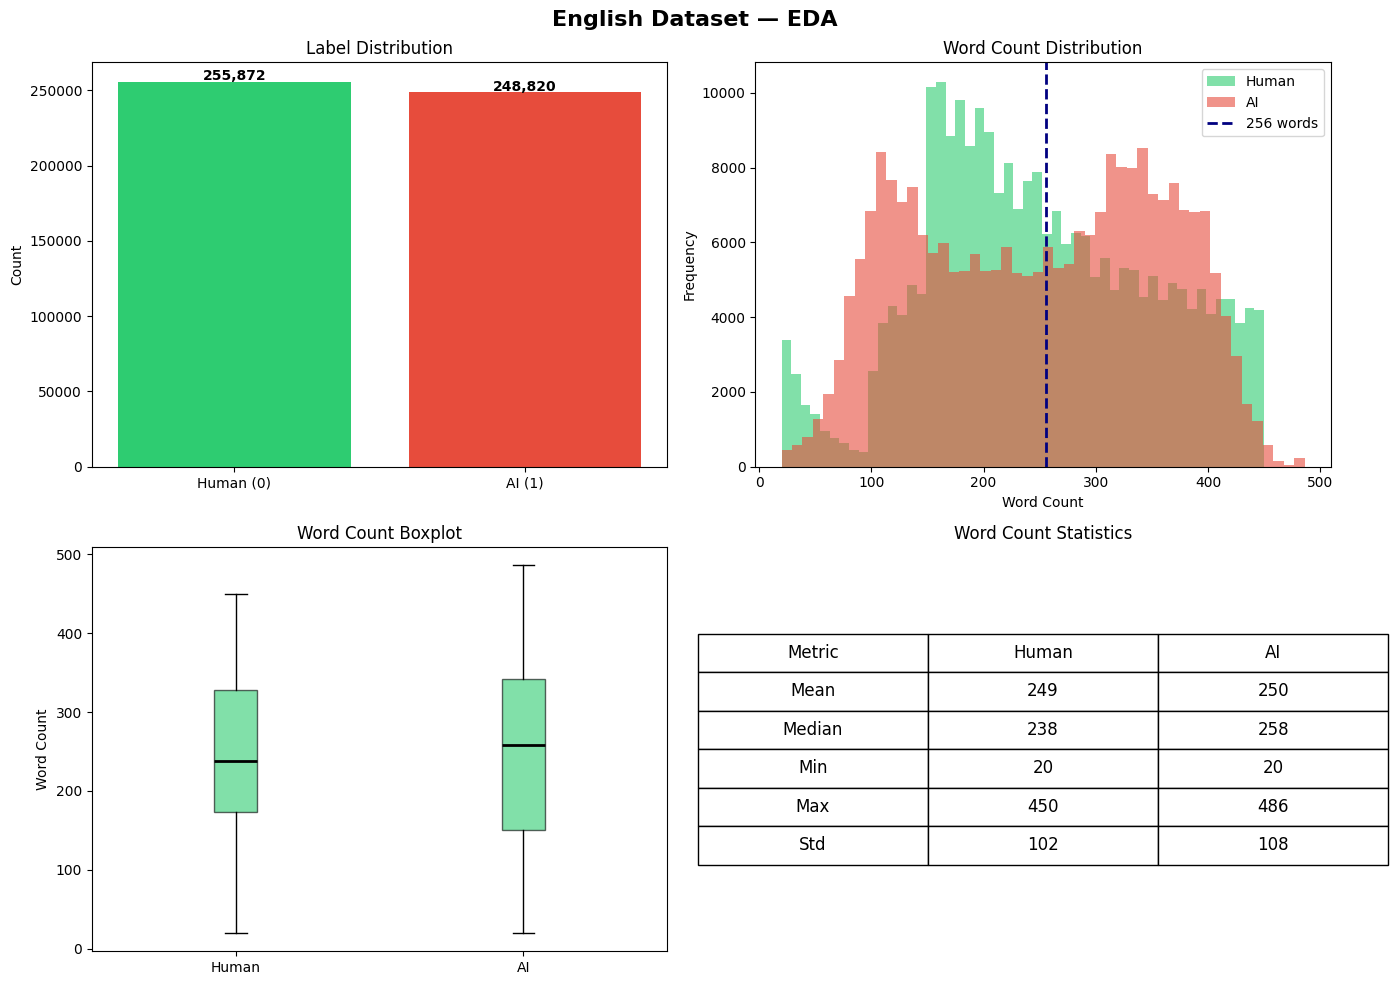

=== Word Count Stats ===

Human — Mean: 249 | Median: 238 | Max: 450
AI    — Mean: 250 | Median: 258 | Max: 486

% texts > 256 words:
  Human : 43.9%
  AI    : 50.3%


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/ramezfawzy/dataset2/english_final (5).csv")
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("English Dataset — EDA", fontsize=16, fontweight="bold")

# 1. Label Distribution
counts = df["label"].value_counts()
axes[0,0].bar(["Human (0)", "AI (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
axes[0,0].set_title("Label Distribution")
axes[0,0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# 2. Word Count Distribution
for label, color, name in [(0, "#2ecc71", "Human"), (1, "#e74c3c", "AI")]:
    subset = df[df["label"] == label]["word_count"]
    axes[0,1].hist(subset.clip(upper=600), bins=50, alpha=0.6, color=color, label=name)
axes[0,1].axvline(256, color="navy", linestyle="--", linewidth=2, label="256 words")
axes[0,1].set_title("Word Count Distribution")
axes[0,1].set_xlabel("Word Count")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# 3. Word Count Boxplot
axes[1,0].boxplot(
    [df[df["label"]==0]["word_count"].clip(upper=600),
     df[df["label"]==1]["word_count"].clip(upper=600)],
    labels=["Human", "AI"],
    patch_artist=True,
    boxprops=dict(facecolor="#2ecc71", alpha=0.6),
    medianprops=dict(color="black", linewidth=2)
)
axes[1,0].set_title("Word Count Boxplot")
axes[1,0].set_ylabel("Word Count")

# 4. Word Count Stats Table
stats = df.groupby("label")["word_count"].describe().round(0)
axes[1,1].axis("off")
table_data = [
    ["Metric", "Human", "AI"],
    ["Mean",   f"{stats.loc[0,'mean']:.0f}", f"{stats.loc[1,'mean']:.0f}"],
    ["Median", f"{stats.loc[0,'50%']:.0f}",  f"{stats.loc[1,'50%']:.0f}"],
    ["Min",    f"{stats.loc[0,'min']:.0f}",   f"{stats.loc[1,'min']:.0f}"],
    ["Max",    f"{stats.loc[0,'max']:.0f}",   f"{stats.loc[1,'max']:.0f}"],
    ["Std",    f"{stats.loc[0,'std']:.0f}",   f"{stats.loc[1,'std']:.0f}"],
]
table = axes[1,1].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
axes[1,1].set_title("Word Count Statistics")

plt.tight_layout()
plt.savefig("english_eda.png", dpi=150)
plt.show()

# Print stats
print("=== Word Count Stats ===")
print(f"\nHuman — Mean: {df[df['label']==0]['word_count'].mean():.0f} | "
      f"Median: {df[df['label']==0]['word_count'].median():.0f} | "
      f"Max: {df[df['label']==0]['word_count'].max():.0f}")
print(f"AI    — Mean: {df[df['label']==1]['word_count'].mean():.0f} | "
      f"Median: {df[df['label']==1]['word_count'].median():.0f} | "
      f"Max: {df[df['label']==1]['word_count'].max():.0f}")
print(f"\n% texts > 256 words:")
print(f"  Human : {(df[df['label']==0]['word_count'] > 256).mean()*100:.1f}%")
print(f"  AI    : {(df[df['label']==1]['word_count'] > 256).mean()*100:.1f}%")

In [21]:
# شوف sample من كل class
print("=== HUMAN SAMPLES ===")
print(df[df['label']==0]['text'].iloc[0])
print("\n" + "="*50)
print(df[df['label']==0]['text'].iloc[1])

print("\n=== AI SAMPLES ===")
print(df[df['label']==1]['text'].iloc[0])
print("\n" + "="*50)
print(df[df['label']==1]['text'].iloc[1])

=== HUMAN SAMPLES ===
to end illegal mining due to its wide-reaching effects in the Water, Sanitation and Hygiene (WASH) areas and most importantly agriculture. He said the stage plays to be organised by his company will not only entertain patrons but to harness their support in the fight against illegal mining. According to him, using stage drama, radio and films to demonstrate the effects of illegal mining will go a long way to win the support of ordinary citizens who otherwise could not have been bothered about the effect of illegal mining. He said theatre is one of the channels that can be used to educate people on the effects of illegal mining. Mr Abubakar explained that the galamsey fight must be embraced by every Ghanaian because of its effect on food crops, water, sanitation and health which cannot be underestimated. “People think because they are not directly involved with galamsey, so it’s not a big deal but the effects are gradually getting to the city centres where people t

In [22]:
import re

def clean(text: str) -> str | None:
    """
    Minimal cleaning for AI detection.
    Preserves: punctuation, quotes, stopwords, casing — all are signal.
    """
    if not isinstance(text, str) or not text.strip():
        return None
    
    # Normalize unicode whitespace
    text = re.sub(r"[\xa0\u200b\u200c\u200d\u2060\ufeff]", " ", text)
    
    # Collapse all whitespace into single space
    text = re.sub(r"\s+", " ", text).strip()
    
    # Drop short texts
    if len(text.split()) < 20:
        return None
    
    return text

In [23]:
df["text"] = df["text"].apply(clean)

before = len(df)
df = df.dropna(subset=["text"]).reset_index(drop=True)
after = len(df)

print(f"Dropped : {before - after:,}")
print(f"Remaining: {after:,}")
print(f"\nLabel dist:\n{df['label'].value_counts()}")

Dropped : 0
Remaining: 504,692

Label dist:
label
0    255872
1    248820
Name: count, dtype: int64


In [24]:
df['has_url']       = df['text'].str.contains(r'http\S+', regex=True)
df['has_newlines']  = df['text'].str.contains(r'\n')
df['has_special']   = df['text'].str.contains(r'[^\x00-\x7F]')
df['leading_space'] = df['text'].str.startswith(' ')
df['has_html']      = df['text'].str.contains(r'<[^>]+>', regex=True)
df['word_count']    = df['text'].str.split().str.len()

print(df.groupby('label')[['has_url','has_newlines',
      'has_special','leading_space','has_html']].mean().round(3)*100)

print("\n=== less than 100 word ===")
print(df[df['word_count'] < 100]['label'].value_counts())

print("\n=== less than 50 word ===")
print(df[df['word_count'] < 50]['label'].value_counts())

       has_url  has_newlines  has_special  leading_space  has_html
label                                                             
0          3.0           0.0         42.6            0.0       0.2
1          2.1           0.0         23.3            0.0       0.5

=== less than 100 word ===
label
1    21644
0    12142
Name: count, dtype: int64

=== less than 50 word ===
label
0    8208
1    2007
Name: count, dtype: int64


In [25]:
df = df[['text', 'label']]

df.describe()

,label
count,504692.000000
mean,0.493014
std,0.499952
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


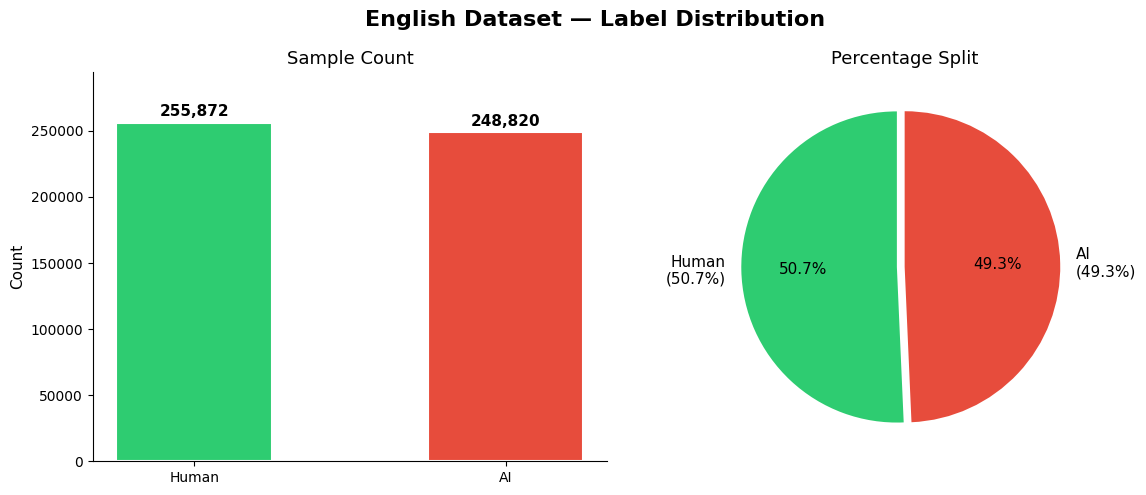

In [27]:
#Plot 1: Label Distribution

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('English Dataset — Label Distribution', fontsize=16, fontweight='bold')

counts      = df['label'].value_counts()
ai_count    = counts.get(1, 0)
human_count = counts.get(0, 0)
total       = ai_count + human_count
ai_pct      = (ai_count / total) * 100
human_pct   = (human_count / total) * 100

# Bar Chart
bars = axes[0].bar(
    ['Human', 'AI'],
    [human_count, ai_count],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[0].set_title('Sample Count', fontsize=13)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_ylim(0, max(ai_count, human_count) * 1.15)
for bar, v in zip(bars, [human_count, ai_count]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + total * 0.01,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie Chart
axes[1].pie(
    [human_count, ai_count],
    labels=[f'Human\n({human_pct:.1f}%)', f'AI\n({ai_pct:.1f}%)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    textprops={'fontsize': 11}
)
axes[1].set_title('Percentage Split', fontsize=13)

plt.tight_layout()
plt.savefig('english_plot1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_57/1345979209.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


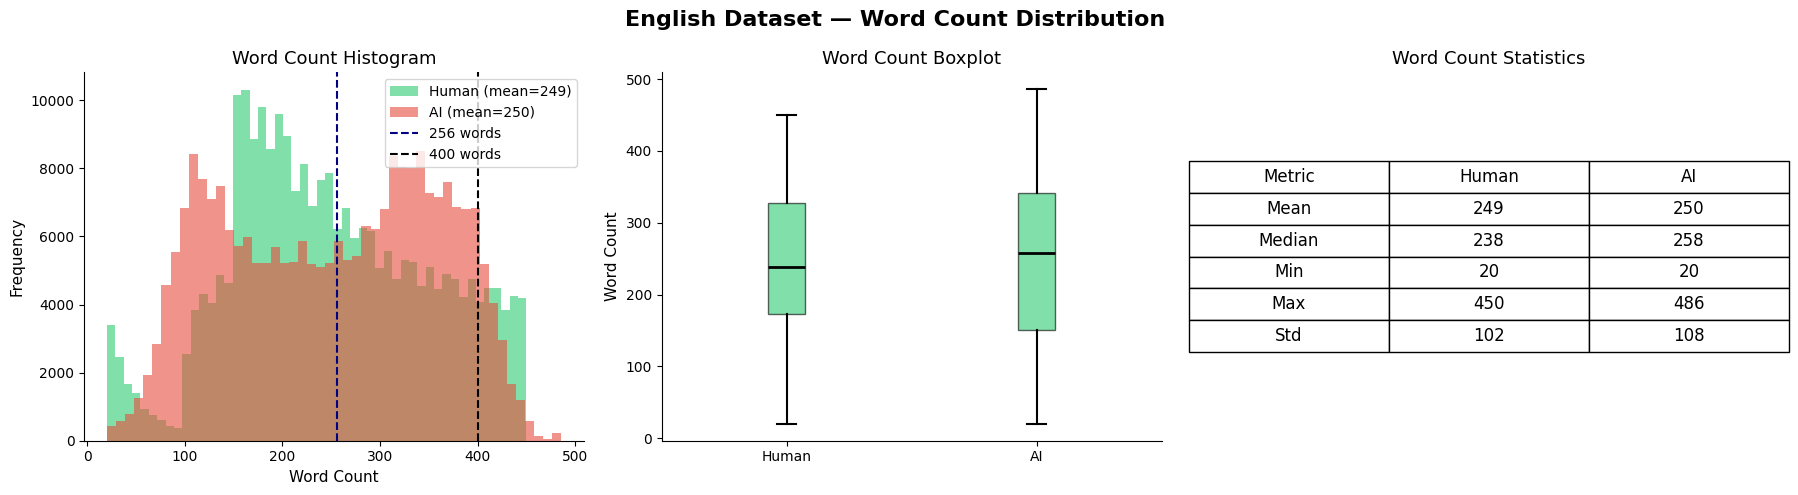

In [28]:
#Plot 2: Word Count by Label

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('English Dataset — Word Count Distribution', fontsize=16, fontweight='bold')

df['word_count'] = df['text'].str.split().str.len()
human_wc = df[df['label'] == 0]['word_count']
ai_wc    = df[df['label'] == 1]['word_count']

# Histogram
axes[0].hist(human_wc.clip(upper=500), bins=50, alpha=0.6, color='#2ecc71', label=f'Human (mean={human_wc.mean():.0f})')
axes[0].hist(ai_wc.clip(upper=500),    bins=50, alpha=0.6, color='#e74c3c', label=f'AI (mean={ai_wc.mean():.0f})')
axes[0].axvline(256, color='navy',  linestyle='--', linewidth=1.5, label='256 words')
axes[0].axvline(400, color='black', linestyle='--', linewidth=1.5, label='400 words')
axes[0].set_title('Word Count Histogram', fontsize=13)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# Boxplot
axes[1].boxplot(
    [human_wc.clip(upper=600), ai_wc.clip(upper=600)],
    labels=['Human', 'AI'],
    patch_artist=True,
    boxprops=dict(facecolor='#2ecc71', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
axes[1].set_title('Word Count Boxplot', fontsize=13)
axes[1].set_ylabel('Word Count', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

# Stats Table
stats = df.groupby('label')['word_count'].describe().round(0)
axes[2].axis('off')
table_data = [
    ['Metric', 'Human', 'AI'],
    ['Mean',   f"{stats.loc[0,'mean']:.0f}",  f"{stats.loc[1,'mean']:.0f}"],
    ['Median', f"{stats.loc[0,'50%']:.0f}",   f"{stats.loc[1,'50%']:.0f}"],
    ['Min',    f"{stats.loc[0,'min']:.0f}",    f"{stats.loc[1,'min']:.0f}"],
    ['Max',    f"{stats.loc[0,'max']:.0f}",    f"{stats.loc[1,'max']:.0f}"],
    ['Std',    f"{stats.loc[0,'std']:.0f}",    f"{stats.loc[1,'std']:.0f}"],
]
table = axes[2].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
axes[2].set_title('Word Count Statistics', fontsize=13)

plt.tight_layout()
plt.savefig('english_plot2_word_count.png', dpi=150, bbox_inches='tight')
plt.show()

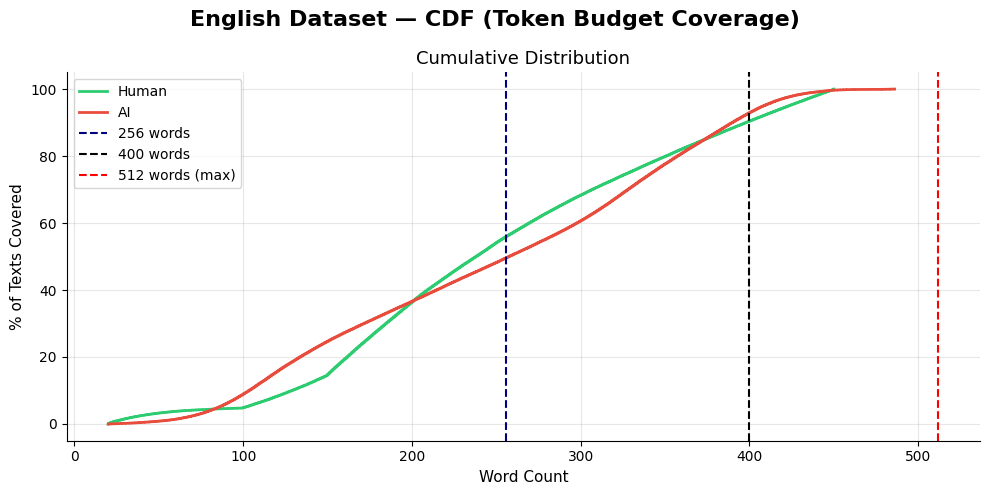

=== Coverage Stats ===

Human:
  < 256 words : 55.8%
  < 400 words : 90.3%
  < 512 words : 100.0%

AI:
  < 256 words : 49.5%
  < 400 words : 92.8%
  < 512 words : 100.0%


In [29]:
#Plot 3: CDF

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('English Dataset — CDF (Token Budget Coverage)', fontsize=16, fontweight='bold')

for label, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
    subset = df[df['label'] == label]['word_count'].sort_values()
    cdf = np.arange(1, len(subset) + 1) / len(subset) * 100
    ax.plot(subset.values, cdf, color=color, label=name, linewidth=2)

ax.axvline(256, color='navy',  linestyle='--', linewidth=1.5, label='256 words')
ax.axvline(400, color='black', linestyle='--', linewidth=1.5, label='400 words')
ax.axvline(512, color='red',   linestyle='--', linewidth=1.5, label='512 words (max)')

ax.set_xlabel('Word Count', fontsize=11)
ax.set_ylabel('% of Texts Covered', fontsize=11)
ax.set_title('Cumulative Distribution', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('english_plot3_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Coverage Stats ===")
for label, name in [(0, 'Human'), (1, 'AI')]:
    wc = df[df['label'] == label]['word_count']
    print(f"\n{name}:")
    print(f"  < 256 words : {(wc < 256).mean()*100:.1f}%")
    print(f"  < 400 words : {(wc < 400).mean()*100:.1f}%")
    print(f"  < 512 words : {(wc < 512).mean()*100:.1f}%")

In [30]:
human_df = df[df['label'] == 0].sample(n=248820, random_state=42)
ai_df    = df[df['label'] == 1]

df = pd.concat([human_df, ai_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df['label'].value_counts())
print("Total:", len(df))

label
0    248820
1    248820
Name: count, dtype: int64
Total: 497640


In [31]:
df.to_csv("final_english_ready_dataset.csv", index=False)
print("Saved ✅")

Saved ✅
